# Taxonomic Classification of WS/DGAT Homologs in Marine Sediment Metagenomes

**Author:** Virginia Galván, PhD  
**Associated publication:** Galván et al. (2023) *PLOS ONE* — https://doi.org/10.1371/journal.pone.0288509  
**Associated thesis:** Galván V. (2026). *Functional characterization of WS/DGAT enzymes from taxonomically diverse uncultured marine microorganisms* — Chapter I, Section 7.3.2

---

## Biological context

Knowing that a microbial community carries WS/DGAT biosynthetic potential (see `01_local_metagenomes_abundance.ipynb`) is only half the picture — identifying **which taxonomic groups carry it** matters directly for biotechnology: it narrows down which lineages to target for cultivation, heterologous expression, or enzyme prospecting, and reveals whether the function is a narrow specialist trait or broadly distributed across the bacterial domain.

This notebook presents the taxonomic composition of WS/DGAT homologs (PF03007) identified in the same 13 marine sediment metagenomes analyzed in Notebook 01 (Subantarctic and Antarctic, Bahía Ushuaia and Potter Cove), and tests whether this composition differs between the two regions.

## Methods summary

WS/DGAT homolog sequences were searched against the NCBI **nr** database with **Blastp** (top 100 hits per query) and classified using the weighted **Lowest Common Ancestor (LCA)** algorithm implemented in **MEGAN6**. Assignments are reported at Phylum and Class level. For assembled metagenomes, abundances were corrected for scaffold read depth (IMG/M).

```
WS/DGAT homolog sequences (PF03007)
        │
        ▼
  Blastp vs nr (top 100 hits)
        │
        ▼
  Weighted LCA (MEGAN6) → Phylum / Class assignment
        │
        ▼
  % composition per metagenome (13 metagenomes)
        │
        ▼
  Grouping into 4 dominant lineages + Other/unassigned
        │
        ▼
  Statistical comparison: Subantarctic vs Antarctic
```

**Input files:**
- `data/taxonomic_assignment_13_metagenomes_repo1.xlsx` — % of WS/DGAT homologs assigned to each Phylum/Class, per metagenome
- `data/Metagenomes_Data_Table.xlsx` — metagenome metadata (region, site)

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

DATA_DIR = '../data' if os.path.exists('../data') else '.'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

# Color scheme: blue = Pseudomonadota, red = Terrabacteria, green = FCB group,
# violet = Acidobacteriota, gray = other / unassigned
GROUP_COLORS = {
    'Pseudomonadota': '#2E86AB',
    'Terrabacteria (Actinomycetota)': '#C0392B',
    'FCB group (Bacteroidota)': '#27AE60',
    'Acidobacteriota': '#8E44AD',
    'Other / unassigned': '#AAAAAA'
}

REGION_COLORS = {'Subantarctic': '#2E86AB', 'Antarctic': '#A23B72'}

METAGENOME_ORDER = ['ARG01', 'ARG02', 'ARG03', 'ARG04', 'ARG05', 'ARG06', 'OR07',
                     'ANT01', 'ANT02', 'ANT03', 'ANT04', 'ANT05', 'ANT06']

print('Setup complete')

Setup complete


## 1. Load data

In [2]:
# --- Taxonomic assignment table: % of WS/DGAT homologs per Phylum/Class, per metagenome ---
# Source: Blastp (vs nr, top 100 hits) + weighted LCA (MEGAN6). Last row is a 100% checksum, dropped here.
tax_raw = pd.read_excel(f'{DATA_DIR}/taxonomic_assignment_13_metagenomes_repo1.xlsx',
                         sheet_name='Hoja1', header=0, index_col=0)
tax_raw = tax_raw.iloc[:-1]
tax_raw.index = tax_raw.index.str.strip()
tax_raw = tax_raw[METAGENOME_ORDER]

# --- Metagenome metadata (region, site) — same table used in Notebook 01 ---
df_meta = pd.read_excel(f'{DATA_DIR}/Metagenomes_Data_Table.xlsx', sheet_name='metagenome_metadata')
df_meta = df_meta.dropna(subset=['metagenome_id', 'region', 'site']).set_index('metagenome_id')
df_meta = df_meta.loc[METAGENOME_ORDER]

print(f'Taxa (Phylum/Class rows): {tax_raw.shape[0]}')
print(f'Metagenomes: {tax_raw.shape[1]}')
tax_raw.round(2).head(10)

Taxa (Phylum/Class rows): 39
Metagenomes: 13


,ARG01,ARG02,ARG03,ARG04,ARG05,ARG06,OR07,ANT01,ANT02,ANT03,ANT04,ANT05,ANT06
Proteobacteria phylum,8.03,9.50,9.96,9.77,6.91,8.03,3.66,9.49,9.38,7.09,9.55,12.86,11.12
Alphaproteobacteria class,1.49,1.28,1.54,1.76,0.89,1.27,4.27,2.19,2.09,1.68,3.22,2.59,2.95
Betaproteobacteria class,0.74,0.38,0.26,0.52,0.27,0.44,3.66,0.57,0.36,0.46,0.35,0.56,0.70
Gammaprotoeobacteria class,49.32,47.36,46.20,36.48,45.65,41.43,20.12,42.12,37.47,44.55,41.58,39.84,44.05
Deltaproteobacteria class,3.76,6.20,6.15,12.90,15.46,14.36,3.05,2.81,4.00,1.47,1.42,2.59,1.90
Epsilonproteobacteria class,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Terrabacteria group,0.41,0.40,0.24,0.91,0.35,0.47,0.00,1.07,1.36,0.58,0.42,0.43,0.21
Actinobacteria phylum,1.37,2.28,1.72,2.41,1.35,1.74,14.63,6.47,7.28,4.55,3.61,4.68,2.97
Acidimicrobiia class,0.62,1.37,1.02,0.59,0.37,0.64,16.46,3.44,3.95,5.13,4.07,4.01,1.49
Actinobacteria class,11.63,11.81,12.02,14.20,10.09,13.15,12.80,10.57,9.05,12.16,9.59,9.66,9.75


## 2. Taxonomic grouping

The raw table reports MEGAN6 assignments at fine Phylum/Class resolution (40 taxa). These are grouped into the **4 dominant lineages** plus an **"Other / unassigned"** category (sequences assigned only to domain Bacteria, not classified, no hits, or belonging to minor phyla each contributing <1%):

| Group | Includes |
|---|---|
| **Pseudomonadota** | Proteobacteria phylum + Alpha/Beta/Gamma/Delta/Epsilon-proteobacteria |
| **Terrabacteria (Actinomycetota)** | Terrabacteria group + Actinobacteria phylum + Acidimicrobiia/Actinobacteria/Nitriliruptoria/Thermoleophilia/Rubrobacteria classes |
| **FCB group (Bacteroidota)** | FCB group + Bacteroidetes phylum + Flavobacteriia/Cytophagia/Bacteroidia classes |
| **Acidobacteriota** | Acidobacteria |
| **Other / unassigned** | Remainder (Chloroflexi, Firmicutes, Archaea, Eukaryota, Bacteria-only, not assigned, no hits, etc.) |

In [3]:
GROUPS = {
    'Pseudomonadota': ['Proteobacteria phylum', 'Alphaproteobacteria class', 'Betaproteobacteria class',
                        'Gammaprotoeobacteria class', 'Deltaproteobacteria class', 'Epsilonproteobacteria class'],
    'Terrabacteria (Actinomycetota)': ['Terrabacteria group', 'Actinobacteria phylum', 'Acidimicrobiia class',
                        'Actinobacteria class', 'Nitriluptoria class', 'Thermoleophilia class', 'Rubrobacteria class'],
    'FCB group (Bacteroidota)': ['FCB group', 'Bacteroidetes phylum', 'Flavobacteriia class',
                        'Cytophagia class', 'Bacteroidia class'],
    'Acidobacteriota': ['Acidobacteria'],
}

grouped = pd.DataFrame({g: tax_raw.loc[rows].sum() for g, rows in GROUPS.items()})
grouped['Other / unassigned'] = 100 - grouped.sum(axis=1)
grouped = grouped[list(GROUP_COLORS.keys())]

assert np.allclose(grouped.sum(axis=1), 100, atol=0.01), 'Group percentages do not sum to 100%'

grouped.round(2)

,Pseudomonadota,Terrabacteria (Actinomycetota),FCB group (Bacteroidota),Acidobacteriota,Other / unassigned
ARG01,63.34,14.03,1.70,0.17,20.77
ARG02,64.71,15.87,1.59,0.18,17.65
ARG03,64.12,15.01,1.48,0.16,19.23
ARG04,61.43,18.11,0.33,0.72,19.41
ARG05,69.16,12.21,0.39,0.67,17.57
ARG06,65.60,16.03,0.89,1.27,16.22
OR07,34.76,45.73,2.44,3.05,14.02
ANT01,57.19,21.57,6.21,0.42,14.60
ANT02,53.30,21.64,9.62,0.59,14.85
ANT03,55.24,22.52,7.52,0.09,14.63


## 3. Figure 1 — Taxonomic composition of WS/DGAT homologs

% of WS/DGAT homologs assigned to each major bacterial lineage, per metagenome.

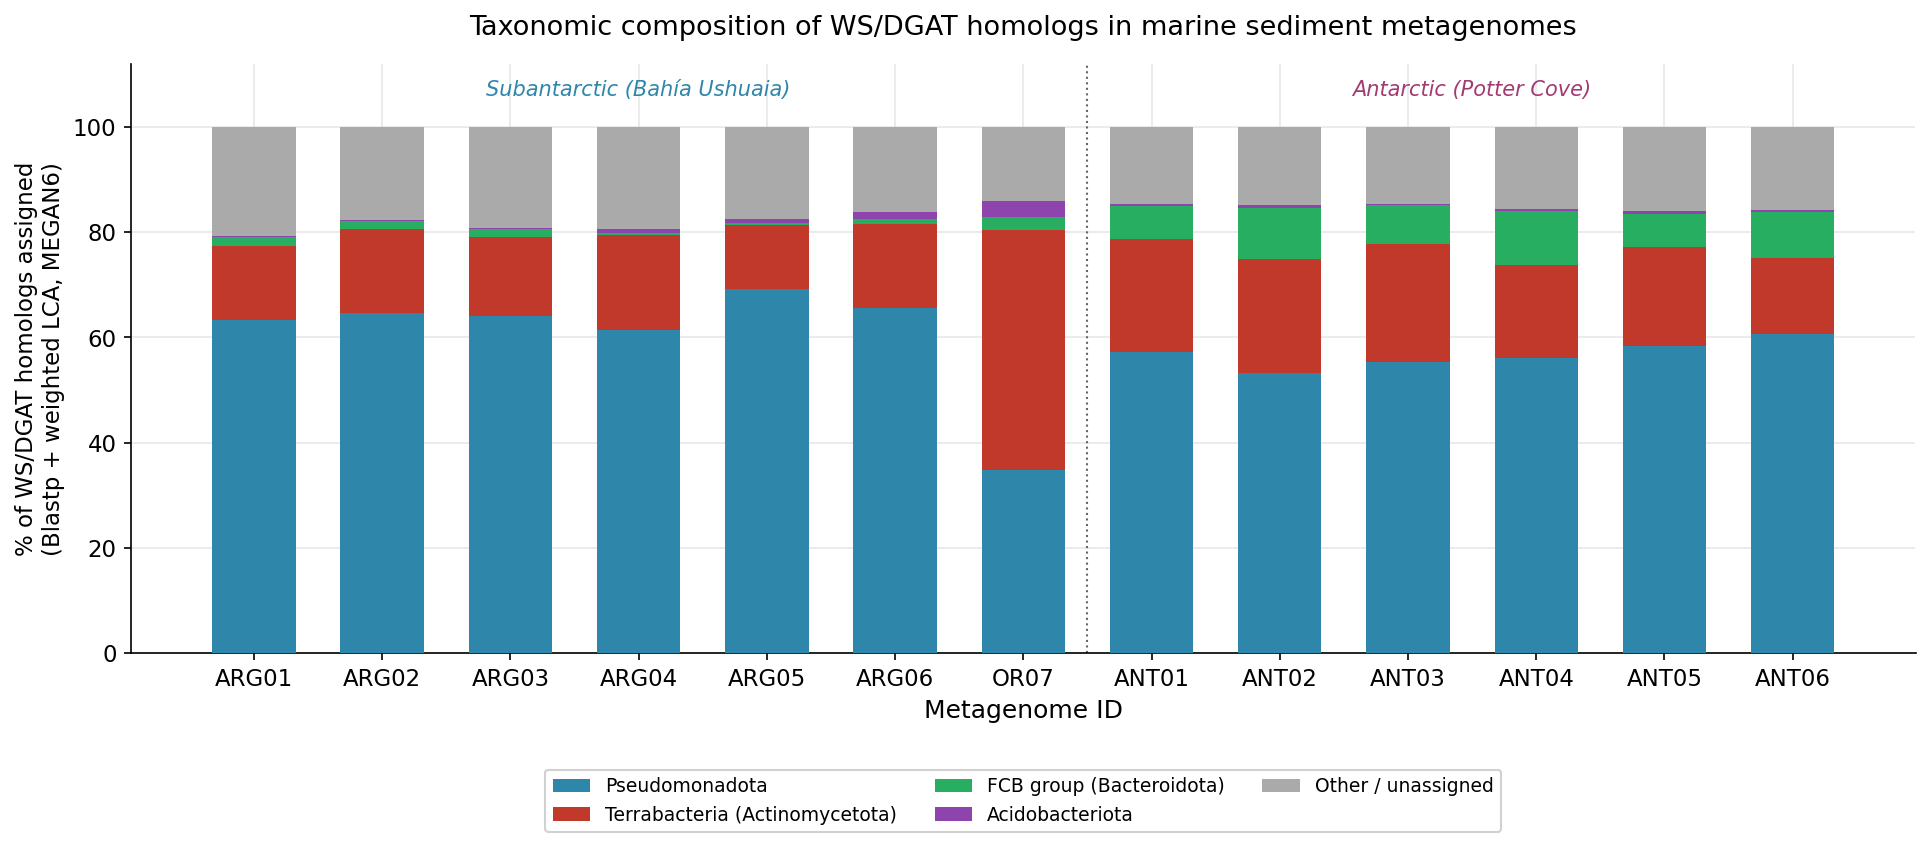

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

bottom = np.zeros(len(grouped))
x = np.arange(len(grouped))
for group, color in GROUP_COLORS.items():
    vals = grouped[group].values
    ax.bar(x, vals, bottom=bottom, color=color, width=0.65, label=group, zorder=3)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=0)
ax.axvline(x=6.5, color='#666666', linestyle=':', linewidth=1, zorder=2)

ax.text(3, 106, 'Subantarctic (Bahía Ushuaia)', ha='center', fontsize=10, color=REGION_COLORS['Subantarctic'], fontstyle='italic')
ax.text(9.5, 106, 'Antarctic (Potter Cove)', ha='center', fontsize=10, color=REGION_COLORS['Antarctic'], fontstyle='italic')

ax.set_ylabel('% of WS/DGAT homologs assigned\n(Blastp + weighted LCA, MEGAN6)', fontsize=11)
ax.set_xlabel('Metagenome ID', fontsize=12)
ax.set_title('Taxonomic composition of WS/DGAT homologs in marine sediment metagenomes', fontsize=13, pad=14)
ax.set_ylim(0, 112)
ax.legend(fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.32), ncol=3, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig1_taxonomic_composition.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data completeness — fraction of sequences resolved at Phylum level or finer

Before interpreting Figure 1, it's worth quantifying how much of the WS/DGAT homolog pool could actually be classified beyond domain level — this sets the ceiling on how finely the "Other / unassigned" slice can be interpreted.

In [5]:
UNRESOLVED = ['Bacteria', 'Bacteria incertae sedis', 'not assigned', 'no hits', 'Archaea',
              'Eukaryota', 'Viruses', 'Cellular organisms/NCBI', 'Environmental samples']

resolved_pct = 100 - tax_raw.loc[UNRESOLVED].sum()

print('% of WS/DGAT homologs resolved at Phylum level or finer, per metagenome:')
print(resolved_pct.round(1))
print()
print(f'Range across all 13 metagenomes: {resolved_pct.min():.1f}% – {resolved_pct.max():.1f}%')

% of WS/DGAT homologs resolved at Phylum level or finer, per metagenome:
ARG01    79.7
ARG02    82.7
ARG03    81.0
ARG04    81.1
ARG05    83.2
ARG06    84.4
OR07     87.2
ANT01    86.2
ANT02    85.9
ANT03    86.0
ANT04    84.8
ANT05    84.5
ANT06    84.5
dtype: float64

Range across all 13 metagenomes: 79.7% – 87.2%


## 5. Statistical analysis — regional differences in taxonomic composition

Two tiers are tested, each corrected for multiple comparisons with the Benjamini-Hochberg FDR procedure (Benjamini & Hochberg, 1995):

1. **Lineage level** — the 5 categories from Figure 1 (Pseudomonadota, Terrabacteria, FCB group, Acidobacteriota, Other/unassigned). Only 5 tests, so the multiple-testing burden is small.
2. **Class level** — every named Class, **excluding** the phylum/group catch-all rows (these represent sequences resolved only to phylum, not a distinct biological group) and **restricted to classes with mean abundance ≥ 1% in at least one region**. Below 1%, most values are at or near zero and Mann-Whitney p-values on that kind of sparse, heavily-tied data are not reliable or biologically meaningful — the filter exists to keep the test set restricted to classes where a "regional difference" is actually interpretable.

Both tiers compare Subantarctic (n=6, ARG01–ARG06) vs Antarctic (n=6, ANT01–ANT06) subtidal metagenomes; OR07 is excluded (different library type and taxonomic assignment method). All tested taxa are reported below — not only the ones that turn out significant — so the result can be judged in context of how many comparisons were actually made.

In [6]:
subant_ids = ['ARG01', 'ARG02', 'ARG03', 'ARG04', 'ARG05', 'ARG06']
antarc_ids = ['ANT01', 'ANT02', 'ANT03', 'ANT04', 'ANT05', 'ANT06']

def benjamini_hochberg(pvals):
    """Benjamini-Hochberg FDR correction (Benjamini & Hochberg, 1995)."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out

# --- Tier 1: lineage level (the 5 categories used in Figure 1) ---
lineage_rows = []
for g in grouped.columns:
    a, b = grouped.loc[subant_ids, g], grouped.loc[antarc_ids, g]
    U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    lineage_rows.append({'Level': 'Lineage', 'Taxon': g,
                          'Subantarctic mean (%)': round(a.mean(), 2),
                          'Antarctic mean (%)': round(b.mean(), 2), 'p-value': p})
lineage_df = pd.DataFrame(lineage_rows)
lineage_df['q-value (BH)'] = benjamini_hochberg(lineage_df['p-value'])

# --- Tier 2: class level, excluding catch-all rows, filtered to >=1% mean abundance in >=1 region ---
CATCHALL_ROWS = {'Proteobacteria phylum', 'Terrabacteria group', 'Actinobacteria phylum',
                  'FCB group', 'Bacteroidetes phylum', 'Bacteria', 'Bacteria incertae sedis',
                  'not assigned', 'no hits', 'Archaea', 'Eukaryota', 'Viruses',
                  'Cellular organisms/NCBI', 'Environmental samples', 'Acidobacteria'}
ABUNDANCE_THRESHOLD = 1.0  # % mean abundance in at least one region

class_rows = []
for t in tax_raw.index:
    if t in CATCHALL_ROWS:
        continue
    a, b = tax_raw.loc[t, subant_ids], tax_raw.loc[t, antarc_ids]
    if max(a.mean(), b.mean()) < ABUNDANCE_THRESHOLD:
        continue
    U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    class_rows.append({'Level': 'Class', 'Taxon': t.replace(' class', ''),
                        'Subantarctic mean (%)': round(a.mean(), 2),
                        'Antarctic mean (%)': round(b.mean(), 2), 'p-value': p})
class_df = pd.DataFrame(class_rows).sort_values('p-value').reset_index(drop=True)
class_df['q-value (BH)'] = benjamini_hochberg(class_df['p-value'])

results_df = pd.concat([lineage_df, class_df], ignore_index=True)
results_df['p-value'] = results_df['p-value'].round(4)
results_df['q-value (BH)'] = results_df['q-value (BH)'].round(4)
results_df['Significant (q<0.05)'] = results_df['q-value (BH)'] < 0.05

print(f'Class-level taxa tested ({ABUNDANCE_THRESHOLD}%+ abundance filter): {len(class_df)} of {tax_raw.shape[0]} total taxa in the table')
results_df

Class-level taxa tested (1.0%+ abundance filter): 7 of 39 total taxa in the table


,Level,Taxon,Subantarctic mean (%),Antarctic mean (%),p-value,q-value (BH),Significant (q<0.05)
0,Lineage,Pseudomonadota,64.73,56.83,0.0022,0.0036,True
1,Lineage,Terrabacteria (Actinomycetota),15.21,19.45,0.0411,0.0514,False
2,Lineage,FCB group (Bacteroidota),1.06,8.09,0.0022,0.0036,True
3,Lineage,Acidobacteriota,0.53,0.37,0.6991,0.6991,False
4,Lineage,Other / unassigned,18.48,15.25,0.0022,0.0036,True
5,Class,Acidimicrobiia,0.77,3.68,0.0022,0.0067,True
6,Class,Flavobacteriia,0.71,4.90,0.0022,0.0067,True
7,Class,Deltaproteobacteria,9.81,2.36,0.0043,0.0067,True
8,Class,Alphaproteobacteria,1.37,2.45,0.0043,0.0067,True
9,Class,Cytophagia,0.05,1.72,0.0048,0.0067,True


## 6. Figure 2 — Class-level regional comparison

All class-level taxa tested in Section 5 (not only the significant ones), ranked by q-value. Every individual metagenome is plotted as a point (n=6 per region); box outlier markers are turned off (`showfliers=False`) since every data point is already shown.

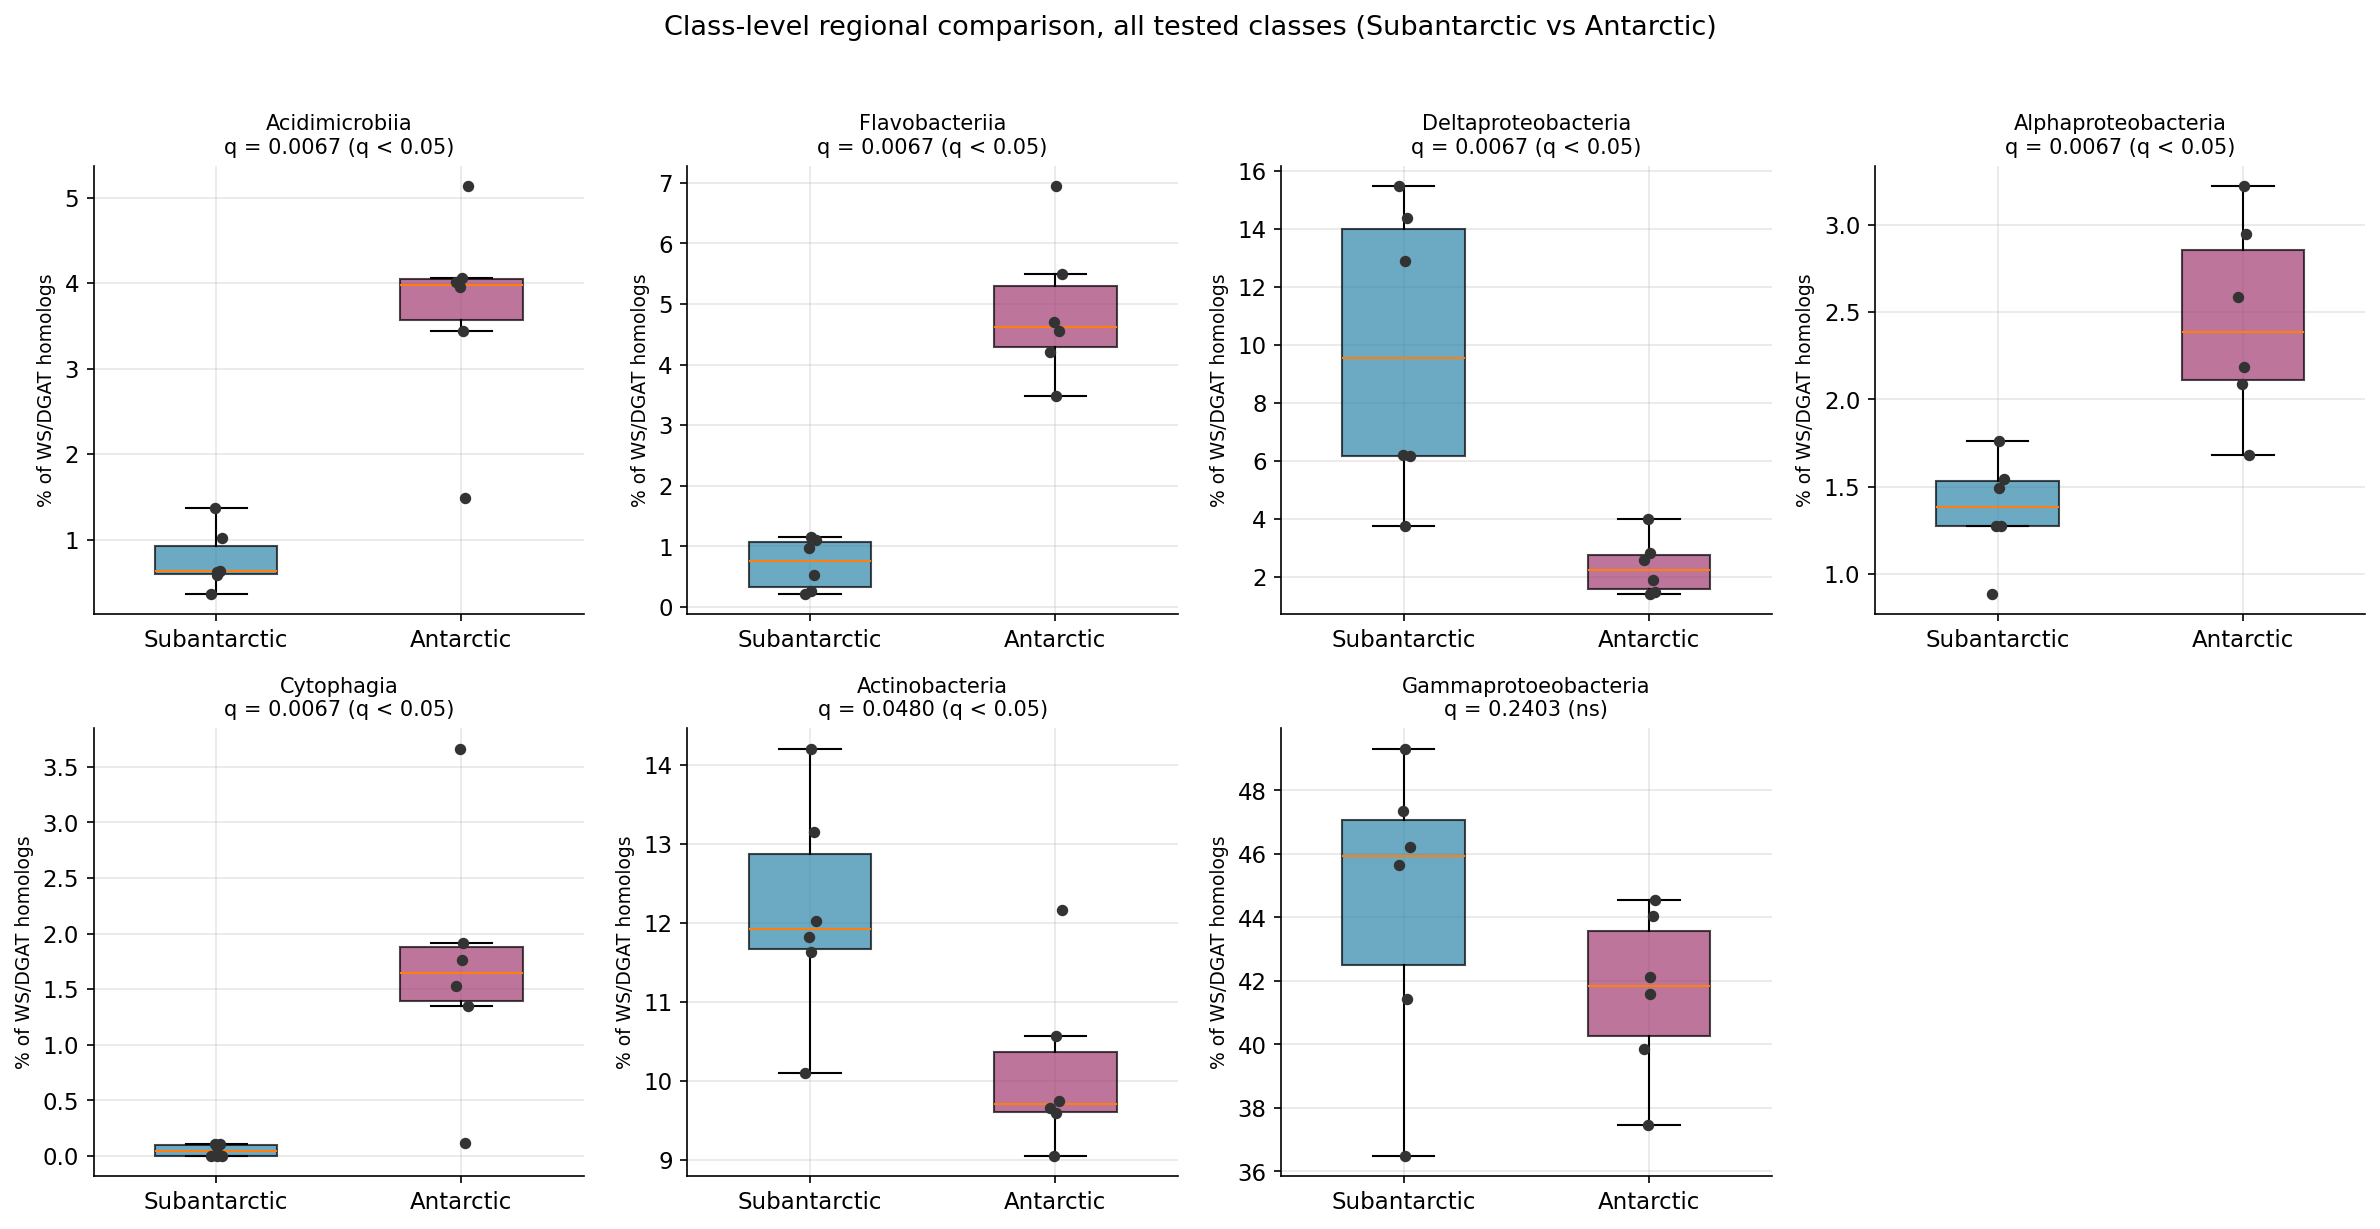

In [7]:
ncols = 4
nrows = int(np.ceil(len(class_df) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, class_df.iterrows()):
    label = row['Taxon']
    row_name = f'{label} class' if f'{label} class' in tax_raw.index else label
    series = tax_raw.loc[row_name]

    data = [series[subant_ids].values, series[antarc_ids].values]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=False,
                     tick_labels=['Subantarctic', 'Antarctic'])
    for patch, region in zip(bp['boxes'], ['Subantarctic', 'Antarctic']):
        patch.set_facecolor(REGION_COLORS[region])
        patch.set_alpha(0.7)
    for i, ids in enumerate([subant_ids, antarc_ids], start=1):
        jitter = np.random.default_rng(0).normal(0, 0.04, size=len(ids))
        ax.scatter(np.full(len(ids), i) + jitter, series[ids].values, color='#333333', s=20, zorder=4)

    q = row['q-value (BH)']
    tag = 'q < 0.05' if q < 0.05 else 'ns'
    ax.set_title(f'{label}\nq = {q:.4f} ({tag})', fontsize=10)
    ax.set_ylabel('% of WS/DGAT homologs', fontsize=9)

for ax in axes[len(class_df):]:
    ax.axis('off')

plt.suptitle('Class-level regional comparison, all tested classes (Subantarctic vs Antarctic)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig2_regional_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Summary table

In [8]:
summary = grouped.round(2).copy()
summary.insert(0, 'Region', df_meta['region'])
summary.insert(1, 'Site', df_meta['site'])
summary.index.name = 'Metagenome'

display(summary)
summary.to_csv('taxonomic_composition_summary.csv')
print('Exported: taxonomic_composition_summary.csv')

,Region,Site,Pseudomonadota,Terrabacteria (Actinomycetota),FCB group (Bacteroidota),Acidobacteriota,Other / unassigned
Metagenome,,,,,,,
ARG01,Subantarctic,MC,63.34,14.03,1.70,0.17,20.77
ARG02,Subantarctic,MC,64.71,15.87,1.59,0.18,17.65
ARG03,Subantarctic,MC,64.12,15.01,1.48,0.16,19.23
ARG04,Subantarctic,OR,61.43,18.11,0.33,0.72,19.41
ARG05,Subantarctic,OR,69.16,12.21,0.39,0.67,17.57
ARG06,Subantarctic,OR,65.60,16.03,0.89,1.27,16.22
OR07,Subantarctic,OR,34.76,45.73,2.44,3.05,14.02
ANT01,Antarctic,S1,57.19,21.57,6.21,0.42,14.60
ANT02,Antarctic,S1,53.30,21.64,9.62,0.59,14.85


Exported: taxonomic_composition_summary.csv


## 8. Key findings

1. **Pseudomonadota dominates the subtidal sediment communities:** across all 12 subtidal metagenomes, Pseudomonadota accounted for 53–69% of taxonomically assigned WS/DGAT homologs — consistently the largest lineage in both Subantarctic and Antarctic sites.

2. **The intertidal sample (OR07) is the exception:** Pseudomonadota dropped to 34.8% in OR07 (Subantarctic, intertidal sediments), with Terrabacteria (predominantly Actinomycetota) taking a much larger share than in any subtidal metagenome — consistent with the distinct sampling matrix and DNA extraction method used for this fosmid library.

3. **Most homologs resolve below domain level:** 79–87% of WS/DGAT homologs across the 13 metagenomes were classified at Phylum level or finer within domain Bacteria; the remainder stayed unresolved (assigned only to domain Bacteria, or with no confident hit).

4. **Regional differences hold up after multiple-testing correction.** At the lineage level (5 categories, BH-corrected), Pseudomonadota, the FCB group, and the unassigned fraction all differ significantly between regions (q = 0.0036); Terrabacteria is borderline (q = 0.051); Acidobacteriota does not differ (q = 0.70).

5. **At class level, 6 of 7 testable classes differ significantly between regions** (≥1% abundance filter, BH-corrected, q < 0.05): Acidimicrobiia, Flavobacteriia and Cytophagia (all enriched in Antarctic sediments), and Deltaproteobacteria, Alphaproteobacteria and Actinobacteria (enriched in Subantarctic sediments, with Deltaproteobacteria showing the largest shift: 9.8% vs 2.4%). **Gammaproteobacteria — the single most abundant class in every metagenome — is the one exception, with no significant regional difference (q = 0.24)**, indicating it is a stable "background" component while the rarer classes around it shift with region.

**Biological implication:** WS/DGAT biosynthetic potential is not confined to a narrow taxonomic niche — it is distributed across Pseudomonadota, Actinomycetota, Bacteroidota, and Acidobacteriota in both polar regions. The dominant carrier (Gammaproteobacteria) stays remarkably constant, but the *secondary* taxonomic structure shifts geographically — relevant when selecting candidate lineages for cultivation or heterologous expression of novel WS/DGAT enzymes from extreme marine environments.

---

## References

- Galván V. et al. (2023). High potential for the biosynthesis of neutral lipid storage compounds in chronically-polluted subantarctic sediments. *PLOS ONE*, 18(7). https://doi.org/10.1371/journal.pone.0288509
- Galván V. (2026). Functional characterization of WS/DGAT enzymes from taxonomically diverse uncultured marine microorganisms. PhD Thesis, Chapter I, Section 7.3.2.
- Huson D.H. et al. (2016). MEGAN Community Edition — interactive exploration and analysis of large-scale microbiome sequencing data. *PLOS Computational Biology*.
- Benjamini Y. & Hochberg Y. (1995). Controlling the False Discovery Rate: A Practical and Powerful Approach to Multiple Testing. *Journal of the Royal Statistical Society, Series B*, 57(1), 289-300.